In [32]:
from _architecture import BaseModel

import numpy as np
import matplotlib.pyplot as plt

In [33]:
X,Y = np.random.randint(low=1,high=30,size=(2,30))

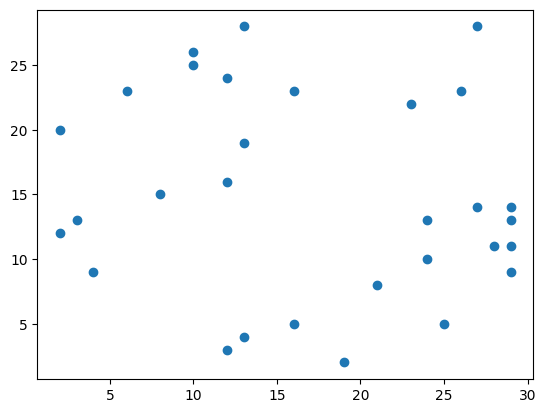

In [34]:
plt.scatter(X,Y)
plt.show()

In [35]:
class simple_linear_regression(BaseModel):

    def __init__(self, *, max_iterations = 10 ** 4, patience = 10 ** 3, lr = 0.0001, verbose : bool = False):
        super().__init__(max_iterations=max_iterations, patience=patience, lr=lr)
        self._verb = verbose


    def _compute_loss(self,y_true, y_pred):

        return np.mean(np.square(y_pred - y_true))
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self._weights = np.zeros(n_features)
        self._bias = 0.0 
        prev_loss = np.inf
        _wait = 0
        tol = 0
        
        for itr in range(self.max_iterations):
            _y = np.dot(X, self._weights) + self._bias
            error = _y - y
            
            w_grad = (2 / n_samples) * np.dot(X.T, error)            
            b_grad = (2 / n_samples) * np.sum(error)

            _loss = self._compute_loss(y, _y)

            self._weights -= (self.lr * w_grad)
            self._bias -= (self.lr * b_grad)

            if abs(prev_loss - _loss) < tol:
                _wait += 1
            else:
                _wait = 0 

            if _wait >= self.patience:
                if self._verb: print(f"Converged at iteration {itr}")
                break

            if self._verb and itr % 1000 == 0:
                print(f'[{itr}/{self.max_iterations}] loss : {_loss:.6f}')

            prev_loss = _loss
                
        self._is_fitted = True
        
        
    def predict(self,X):
        
        return X*self._weights + self._bias
    
    def score(self, y_true, y_pred):
        return self._compute_loss(y_true,y_pred)
    

    

In [36]:
lr_reg = simple_linear_regression(max_iterations = int(5e5),verbose=True, lr = 1e-4)

X_ = np.expand_dims(X,1)
lr_reg.fit(X_,Y)

[0/500000] loss : 281.600000
[1000/500000] loss : 115.930941
[2000/500000] loss : 111.036027
[3000/500000] loss : 106.549046
[4000/500000] loss : 102.436002
[5000/500000] loss : 98.665732
[6000/500000] loss : 95.209670
[7000/500000] loss : 92.041631
[8000/500000] loss : 89.137610
[9000/500000] loss : 86.475605
[10000/500000] loss : 84.035447
[11000/500000] loss : 81.798647
[12000/500000] loss : 79.748259
[13000/500000] loss : 77.868746
[14000/500000] loss : 76.145869
[15000/500000] loss : 74.566573
[16000/500000] loss : 73.118893
[17000/500000] loss : 71.791861
[18000/500000] loss : 70.575420
[19000/500000] loss : 69.460356
[20000/500000] loss : 68.438220
[21000/500000] loss : 67.501266
[22000/500000] loss : 66.642397
[23000/500000] loss : 65.855104
[24000/500000] loss : 65.133423
[25000/500000] loss : 64.471885
[26000/500000] loss : 63.865479
[27000/500000] loss : 63.309610
[28000/500000] loss : 62.800066
[29000/500000] loss : 62.332986
[30000/500000] loss : 61.904832
[31000/500000] l

In [37]:
y_pred = lr_reg.predict(X_)
y_pred

array([[14.02288029],
       [16.64918714],
       [13.7602496 ],
       [13.36630358],
       [15.5986644 ],
       [13.36630358],
       [15.86129509],
       [14.02288029],
       [14.15419563],
       [13.62893426],
       [14.679457  ],
       [15.46734906],
       [13.36630358],
       [15.46734906],
       [14.41682632],
       [16.91181783],
       [16.38655646],
       [15.86129509],
       [15.07340303],
       [13.62893426],
       [13.49761892],
       [13.89156495],
       [16.91181783],
       [15.07340303],
       [13.36630358],
       [15.46734906],
       [16.12392577],
       [15.5986644 ],
       [16.78050249],
       [15.5986644 ]])

In [38]:
print('RMSE : ',lr_reg.score(Y,y_pred))

RMSE :  59.99566891709082


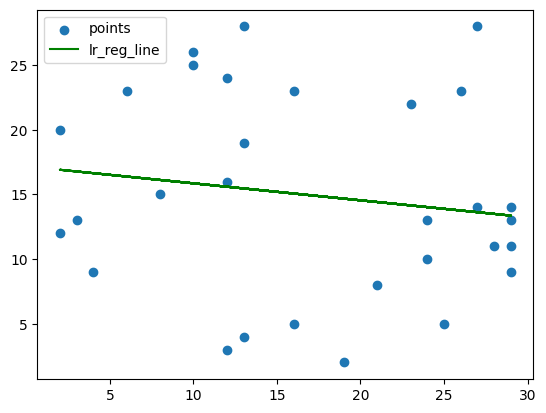

In [39]:
plt.scatter(X,Y,label='points')
plt.plot(X,y_pred,label='lr_reg_line',color="green")
plt.legend()
plt.show()

### Lets check our custom model performance against real model


In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


lr_reg_2 = LinearRegression()
lr_reg_2.fit(X_,Y)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [41]:
y_pred_2 = lr_reg_2.predict(X_)
print(y_pred_2)
print('RMSE : ',mean_squared_error(Y,y_pred_2))

[14.02288029 16.64918715 13.7602496  13.36630357 15.5986644  13.36630357
 15.86129509 14.02288029 14.15419563 13.62893426 14.679457   15.46734906
 13.36630357 15.46734906 14.41682632 16.91181783 16.38655646 15.86129509
 15.07340303 13.62893426 13.49761892 13.89156495 16.91181783 15.07340303
 13.36630357 15.46734906 16.12392578 15.5986644  16.78050249 15.5986644 ]
RMSE :  57.19544218804167


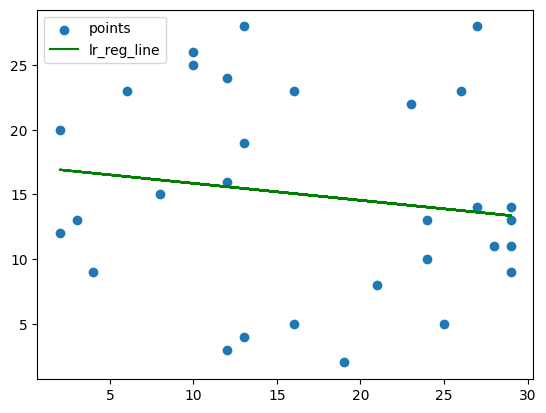

In [42]:
plt.scatter(X,Y,label='points')
plt.plot(X,y_pred_2,label='lr_reg_line',color="green")
plt.legend()
plt.show()

In [43]:
np.sum(y_pred_2 - y_pred.squeeze())

np.float64(3.990827934785557e-08)

In [44]:
## sklearn linear regression is way faster and accurate !!

In [50]:
class OLSLinearRegression(BaseModel):

    def __init__(self):
        self._is_fitted = False

    def fit(self, X, y):
        n_samples = X.shape[0]
        _X = np.c_[np.ones(n_samples), X]
        # w  = (X^T * X)^-1 * X^T * y
        weights_full = np.linalg.inv(_X.T @ _X) @ _X.T @ y
        
        self.bias_ = weights_full[0]
        self.weights_ = weights_full[1:]
        self._is_fitted = True

    def _compute_loss(self,y_true, y_pred):
        return np.mean(np.square(y_true-y_pred))

    def score(self, y_true, y_pred):
        return self._compute_loss(y_true,y_pred)        

    def predict(self, X):
        return np.dot(X, self.weights_) + self.bias_


In [51]:
lr_os_reg = OLSLinearRegression()
lr_os_reg.fit(X_,Y)


In [52]:
y_pred_3 = lr_os_reg.predict(X_)
y_pred_3

array([14.02288029, 16.64918715, 13.7602496 , 13.36630357, 15.5986644 ,
       13.36630357, 15.86129509, 14.02288029, 14.15419563, 13.62893426,
       14.679457  , 15.46734906, 13.36630357, 15.46734906, 14.41682632,
       16.91181783, 16.38655646, 15.86129509, 15.07340303, 13.62893426,
       13.49761892, 13.89156495, 16.91181783, 15.07340303, 13.36630357,
       15.46734906, 16.12392578, 15.5986644 , 16.78050249, 15.5986644 ])

In [53]:
print('RMSE : ',lr_os_reg.score(Y,y_pred_3))

RMSE :  57.19544218804167


In [ ]:
# now we're equal !!
# sklearn uses OLS based approach to directly reach to the bottom of optimization space without going through any iterative process.

# It uses LAPACK dgelsd (via scipy.linalg.lstsq). This is a solver based on Singular Value Decomposition (SVD). 